# Assignment 4: Denoising Diffusion Probabilistic Model (DDPM)
## Generative AI — AI4009 | Spring 2026
### National University of Computer and Emerging Sciences

**Objective:** Implement a DDPM from scratch using base PyTorch only (no HuggingFace Diffusers, no pretrained models).  
**Platform:** Kaggle (GPU T4 × 2)  
**Dataset:** CelebA-HQ 256 / FFHQ / WikiArt  

---

## 0. Install & Import Dependencies

In [1]:
# Install extra packages
!pip install -q scikit-image einops

In [2]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device Setup (Dual-GPU aware) ────────────────────────────────────────────
if torch.cuda.device_count() >= 2:
    DEVICE = torch.device("cuda:0")
    USE_MULTI_GPU = True
    print(f" Dual-GPU mode: {torch.cuda.get_device_name(0)} + {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    USE_MULTI_GPU = False
    print(f" Single-GPU mode: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    USE_MULTI_GPU = False
    print("  Running on CPU — training will be slow")

print(f"PyTorch version : {torch.__version__}")
print(f"Active device   : {DEVICE}")

 Dual-GPU mode: Tesla T4 + Tesla T4
PyTorch version : 2.10.0+cu128
Active device   : cuda:0


## 1. Global Configuration

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  Central config — change IMAGE_SIZE to 256 for higher-quality results
# ─────────────────────────────────────────────────────────────────────────────
class Config:
    # Data
    # Update DATA_ROOT to the Kaggle dataset path you select
    DATA_ROOT   = "/kaggle/input/datasets/denislukovnikov/celebahq256-images-only"  # CelebA-HQ
    # DATA_ROOT = "/kaggle/input/ffhq-face-data-set/images1024x1024"   # FFHQ
    # DATA_ROOT = "/kaggle/input/wikiart/wikiart"                       # WikiArt

    IMAGE_SIZE  = 128          # 128 (minimum) or 256 (recommended)
    CHANNELS    = 3

    # Diffusion
    T           = 300          # total diffusion timesteps  (200–500 recommended)
    BETA_START  = 1e-4
    BETA_END    = 0.02
    SCHEDULE    = "cosine"     # "linear" or "cosine"

    # U-Net
    BASE_CH     = 64           # channel progression 64→128→256
    CH_MULT     = (1, 2, 4)    # 64, 128, 256
    NUM_RES     = 2            # residual blocks per level
    ATTN_RES    = (16,)        # apply self-attention at these spatial sizes
    DROPOUT     = 0.1

    # Training
    EPOCHS      = 30           # increase for better quality
    BATCH_SIZE  = 16
    LR          = 2e-4
    GRAD_CLIP   = 1.0
    USE_AMP     = True         # mixed-precision
    NUM_WORKERS = 4

    # Output
    SAVE_DIR    = "/kaggle/working/ddpm_outputs"
    CKPT_DIR    = "/kaggle/working/ddpm_checkpoints"
    SAVE_EVERY  = 5            # save checkpoint every N epochs
    VIS_EVERY   = 5            # visualise every N epochs

cfg = Config()

os.makedirs(cfg.SAVE_DIR, exist_ok=True)
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
print("Config loaded ")

Config loaded 


## 2. Part 1 — Data Preprocessing

In [4]:
class ImageFolderDataset(Dataset):
    """Lightweight dataset that recursively finds images in a folder tree."""
    EXTS = {".jpg", ".jpeg", ".png", ".webp"}

    def __init__(self, root: str, image_size: int, max_samples: int = None):
        self.root = Path(root)
        self.files = sorted([
            p for p in self.root.rglob("*")
            if p.suffix.lower() in self.EXTS
        ])
        if max_samples:
            self.files = self.files[:max_samples]
        assert len(self.files) > 0, f"No images found under {root}"

        self.transform = transforms.Compose([
            transforms.Resize(image_size, interpolation=transforms.InterpolationMode.LANCZOS),
            transforms.CenterCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],   # maps [0,1] → [-1,1]
                                  [0.5, 0.5, 0.5]),
        ])
        print(f"Dataset: {len(self.files)} images  |  size: {image_size}×{image_size}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        return self.transform(img)


# ── Build dataset & dataloader ────────────────────────────────────────────────
dataset = ImageFolderDataset(
    root=cfg.DATA_ROOT,
    image_size=cfg.IMAGE_SIZE,
    max_samples=10_000   # cap for speed; remove for full dataset
)

dataloader = DataLoader(
    dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

print(f"Batches per epoch: {len(dataloader)}")

# ── Quick sanity check ────────────────────────────────────────────────────────
sample_batch = next(iter(dataloader))
print(f"Batch shape : {sample_batch.shape}")
print(f"Value range : [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")

Dataset: 10000 images  |  size: 128×128
Batches per epoch: 625
Batch shape : torch.Size([16, 3, 128, 128])
Value range : [-1.00, 1.00]


## 3. Part 2 — Forward Diffusion Process

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  Noise Schedule
# ─────────────────────────────────────────────────────────────────────────────
def make_beta_schedule(schedule: str, T: int, beta_start: float, beta_end: float):
    if schedule == "linear":
        return torch.linspace(beta_start, beta_end, T)
    elif schedule == "cosine":
        # Improved cosine schedule (Nichol & Dhariwal 2021)
        s = 0.008
        steps = T + 1
        t = torch.linspace(0, T, steps) / T
        alpha_bar = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
        alpha_bar = alpha_bar / alpha_bar[0]
        betas = 1 - (alpha_bar[1:] / alpha_bar[:-1])
        return betas.clamp(0, 0.999)
    else:
        raise ValueError(f"Unknown schedule: {schedule}")


class ForwardDiffusion:
    """
    Fixed forward process:  q(x_t | x_0) = N(sqrt(ā_t)*x_0, (1-ā_t)*I)
    So we can jump directly to any timestep in one shot.
    """

    def __init__(self, cfg: Config, device):
        self.T      = cfg.T
        self.device = device

        betas = make_beta_schedule(cfg.SCHEDULE, cfg.T, cfg.BETA_START, cfg.BETA_END)
        alphas       = 1.0 - betas
        alpha_bar    = torch.cumprod(alphas, dim=0)     # ā_t
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)

        def reg(x): return x.float().to(device)

        self.betas           = reg(betas)
        self.alphas          = reg(alphas)
        self.alpha_bar       = reg(alpha_bar)
        self.alpha_bar_prev  = reg(alpha_bar_prev)
        self.sqrt_alpha_bar        = reg(alpha_bar.sqrt())
        self.sqrt_one_minus_ab     = reg((1 - alpha_bar).sqrt())
        self.log_one_minus_ab      = reg((1 - alpha_bar).log())
        self.sqrt_recip_alpha_bar  = reg((1 / alpha_bar).sqrt())
        self.sqrt_recip_m1_ab      = reg((1 / alpha_bar - 1).sqrt())

        # Posterior variance q(x_{t-1}|x_t, x_0)
        self.posterior_var = reg(
            betas * (1 - alpha_bar_prev) / (1 - alpha_bar)
        )
        self.posterior_log_var_clip = reg(
            torch.log(self.posterior_var.clamp(min=1e-20))
        )
        self.posterior_mean_c1 = reg(betas * alpha_bar_prev.sqrt() / (1 - alpha_bar))
        self.posterior_mean_c2 = reg((1 - alpha_bar_prev) * alphas.sqrt() / (1 - alpha_bar))

    # ── helpers ───────────────────────────────────────────────────────────────
    @staticmethod
    def _extract(arr, t, x_shape):
        """Index arr at timesteps t and broadcast to x_shape."""
        B = t.shape[0]
        out = arr[t]           # (B,)
        return out.reshape(B, *((1,) * (len(x_shape) - 1)))

    # ── forward ───────────────────────────────────────────────────────────────
    def q_sample(self, x0, t, noise=None):
        """Add noise to x0 at timestep t.  Returns (x_t, noise)."""
        if noise is None:
            noise = torch.randn_like(x0)
        s1 = self._extract(self.sqrt_alpha_bar,    t, x0.shape)
        s2 = self._extract(self.sqrt_one_minus_ab, t, x0.shape)
        return s1 * x0 + s2 * noise, noise

    # ── reverse ───────────────────────────────────────────────────────────────
    def predict_x0_from_eps(self, x_t, t, eps):
        """Reconstruct x0 from predicted noise epsilon."""
        c1 = self._extract(self.sqrt_recip_alpha_bar, t, x_t.shape)
        c2 = self._extract(self.sqrt_recip_m1_ab,     t, x_t.shape)
        return c1 * x_t - c2 * eps

    def q_posterior_mean_var(self, x0, x_t, t):
        """Posterior mean & log-var of q(x_{t-1}|x_t, x_0)."""
        c1  = self._extract(self.posterior_mean_c1,    t, x_t.shape)
        c2  = self._extract(self.posterior_mean_c2,    t, x_t.shape)
        mean = c1 * x0 + c2 * x_t
        log_var = self._extract(self.posterior_log_var_clip, t, x_t.shape)
        return mean, log_var

    @torch.no_grad()
    def p_sample(self, model, x_t, t_scalar: int):
        """One reverse step: x_{t-1} ~ p_θ(x_{t-1}|x_t)."""
        B = x_t.shape[0]
        t = torch.full((B,), t_scalar, dtype=torch.long, device=self.device)

        eps_pred = model(x_t, t)
        x0_pred  = self.predict_x0_from_eps(x_t, t, eps_pred).clamp(-1, 1)
        mean, log_var = self.q_posterior_mean_var(x0_pred, x_t, t)

        noise = torch.randn_like(x_t) if t_scalar > 0 else torch.zeros_like(x_t)
        return mean + (0.5 * log_var).exp() * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape, capture_steps=None):
        """Full reverse loop from pure noise. Returns final image (and intermediates)."""
        model.eval()
        x = torch.randn(shape, device=self.device)
        intermediates = []

        for t in tqdm(reversed(range(self.T)), desc="Denoising", total=self.T, leave=False):
            x = self.p_sample(model, x, t)
            if capture_steps is not None and t in capture_steps:
                intermediates.append(x.cpu().clone())

        return x, intermediates


fd = ForwardDiffusion(cfg, DEVICE)
print("Forward Diffusion object built ")
print(f"Beta range : [{fd.betas.min():.5f}, {fd.betas.max():.5f}]")
print(f"ᾱ at T=1   : {fd.alpha_bar[0]:.4f}")
print(f"ᾱ at T={cfg.T}  : {fd.alpha_bar[-1]:.4f}")

Forward Diffusion object built 
Beta range : [0.00016, 0.99900]
ᾱ at T=1   : 0.9998
ᾱ at T=300  : 0.0000


### Visualise 5 Forward Noising Steps

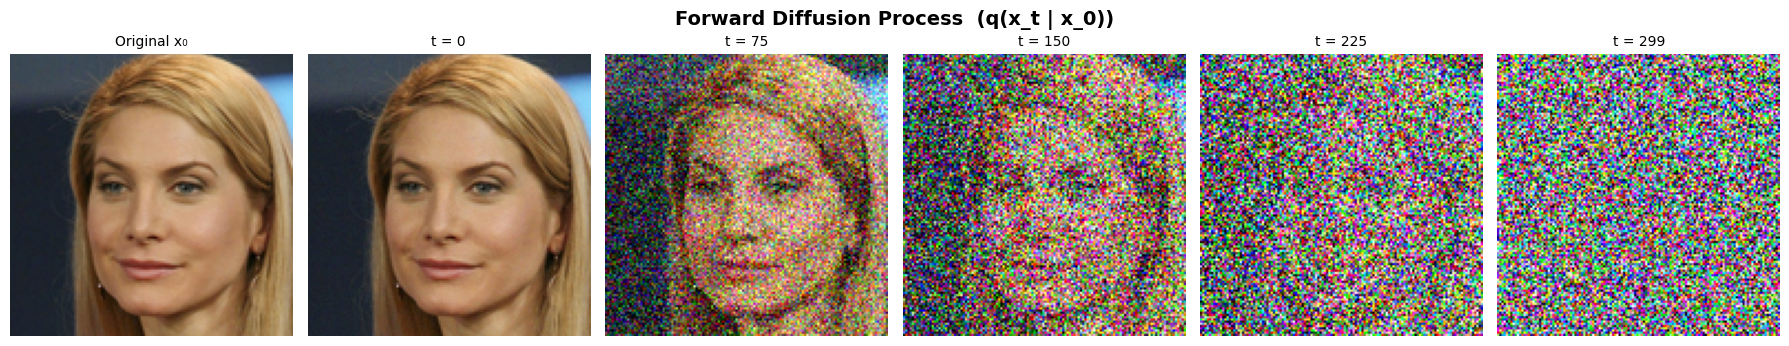

In [6]:
def tensor_to_img(t):
    """Convert [-1,1] tensor (C,H,W) → numpy uint8 (H,W,C)."""
    t = ((t.clamp(-1, 1) + 1) / 2 * 255).byte()
    return t.permute(1, 2, 0).cpu().numpy()


def visualise_forward(x0: torch.Tensor, fd: ForwardDiffusion, steps=5):
    """Show original + noisy versions at 5 evenly-spaced timesteps."""
    T = fd.T
    timesteps = [int(T * i / (steps - 1)) for i in range(steps)]
    timesteps[-1] = T - 1   # clamp to valid index

    fig, axes = plt.subplots(1, steps + 1, figsize=(3 * (steps + 1), 3.5))
    fig.suptitle("Forward Diffusion Process  (q(x_t | x_0))", fontsize=14, fontweight="bold")

    axes[0].imshow(tensor_to_img(x0))
    axes[0].set_title("Original x₀", fontsize=10)
    axes[0].axis("off")

    x0_d = x0.unsqueeze(0).to(DEVICE)
    for ax, ts in zip(axes[1:], timesteps):
        t_tensor = torch.tensor([ts], device=DEVICE)
        x_t, _ = fd.q_sample(x0_d, t_tensor)
        ax.imshow(tensor_to_img(x_t.squeeze(0)))
        ax.set_title(f"t = {ts}", fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"{cfg.SAVE_DIR}/forward_diffusion.png", dpi=120, bbox_inches="tight")
    plt.show()


# grab a single image from the first batch
ref_img = sample_batch[0]   # (3, H, W)  in [-1,1]
visualise_forward(ref_img, fd, steps=5)

## 4. Part 3 — U-Net Architecture

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  Building Blocks
# ─────────────────────────────────────────────────────────────────────────────

class SinusoidalPositionEmbedding(nn.Module):
    """Sinusoidal timestep embedding (same as Transformer positional encoding)."""

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        device = t.device
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=device) / (half - 1)
        )
        args = t[:, None].float() * freqs[None]
        emb  = torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)
        return emb


class TimeEmbedding(nn.Module):
    """Two-layer MLP that projects sinusoidal embeddings to a richer space."""

    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            SinusoidalPositionEmbedding(dim),
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim * 4),
        )

    def forward(self, t):
        return self.net(t)


class GroupNorm(nn.GroupNorm):
    """Convenience wrapper with sensible default for small channel counts."""
    def __init__(self, channels):
        groups = min(32, channels)   # avoid group > channels
        super().__init__(groups, channels)


class ResBlock(nn.Module):
    """
    Residual block with:
      • GroupNorm + SiLU activation
      • Time-step conditioning via additive shift
      • Optional channel-resize skip connection
    """

    def __init__(self, in_ch: int, out_ch: int, time_emb_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = GroupNorm(in_ch)
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2 = GroupNorm(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.dropout = nn.Dropout(dropout)

        # Project time embedding to out_ch
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )

        # Skip connection
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, time_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_mlp(time_emb)[:, :, None, None]   # broadcast to spatial
        h = self.dropout(self.conv2(F.silu(self.norm2(h))))
        return h + self.skip(x)


class SelfAttention(nn.Module):
    """Efficient multi-head self-attention for 2-D feature maps."""

    def __init__(self, channels: int, heads: int = 4):
        super().__init__()
        self.heads = heads
        self.head_dim = channels // heads
        self.scale = self.head_dim ** -0.5

        self.norm  = GroupNorm(channels)
        self.qkv   = nn.Conv2d(channels, channels * 3, 1, bias=False)
        self.proj  = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, self.heads, self.head_dim, H * W)
        q, k, v = qkv.unbind(dim=1)                     # each (B, heads, head_dim, HW)
        attn = torch.einsum("bhdi,bhdj->bhij", q, k) * self.scale
        attn = attn.softmax(dim=-1)
        out  = torch.einsum("bhij,bhdj->bhdi", attn, v)
        out  = out.reshape(B, C, H, W)
        return x + self.proj(out)


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x, *args): return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x, *args): return self.conv(self.up(x))


print("Building blocks defined ")

Building blocks defined 


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  U-Net  (encoder → bottleneck → decoder with skip connections)
# ─────────────────────────────────────────────────────────────────────────────

class UNetClean(nn.Module):
    """
    Clean U-Net for DDPM.
    Channel progression: 64 → 128 → 256

    Skip-connection accounting
    --------------------------
    Encoder saves skips:
      • 1 skip from init_conv  (at full resolution)
      • num_res skips per encoder level  (after each ResBlock)
      Total = 1 + num_res * len(ch_mult)

    With NUM_RES=2, CH_MULT=(1,2,4):
      total skips = 1 + 2*3 = 7
      resolutions = [128, 128, 128, 64, 64, 32, 32]

    Decoder consumes skips in reverse:
      • level 2 (deepest, no upsample first): num_res blocks  → 2 pops
      • level 1 (upsample first):             num_res blocks  → 2 pops
      • level 0 (upsample first):             num_res+1 blocks → 3 pops (uses init_conv skip)
      Total = 2 + 2 + 3 = 7  ✓

    Upsample happens BEFORE the skip-cat blocks so spatial dims always match.
    """

    def __init__(self, cfg):
        super().__init__()
        in_ch    = cfg.CHANNELS
        base_ch  = cfg.BASE_CH
        ch_mult  = cfg.CH_MULT
        num_res  = cfg.NUM_RES
        attn_res = set(cfg.ATTN_RES)
        dropout  = cfg.DROPOUT
        img_size = cfg.IMAGE_SIZE

        self.num_res = num_res
        self.ch_mult = ch_mult
        self.levels  = len(ch_mult)

        time_dim = base_ch * 4
        self.time_emb  = TimeEmbedding(base_ch)
        self.init_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        # ── Encoder ───────────────────────────────────────────────────────────
        self.enc_res  = nn.ModuleList()
        self.enc_attn = nn.ModuleList()
        self.enc_down = nn.ModuleList()
        self.skip_channels = [base_ch]   # first skip: init_conv output

        ch  = base_ch
        res = img_size

        for level, mult in enumerate(ch_mult):
            out_ch = base_ch * mult
            for _ in range(num_res):
                self.enc_res.append(ResBlock(ch, out_ch, time_dim, dropout))
                self.enc_attn.append(
                    SelfAttention(out_ch) if res in attn_res else nn.Identity()
                )
                self.skip_channels.append(out_ch)
                ch = out_ch
            # Downsample (or identity at the last level) — no skip saved here
            if level < len(ch_mult) - 1:
                self.enc_down.append(Downsample(ch))
                res //= 2
            else:
                self.enc_down.append(nn.Identity())

        # ── Bottleneck ────────────────────────────────────────────────────────
        self.mid1     = ResBlock(ch, ch, time_dim, dropout)
        self.mid_attn = SelfAttention(ch)
        self.mid2     = ResBlock(ch, ch, time_dim, dropout)

        # ── Decoder ───────────────────────────────────────────────────────────
        # Upsample FIRST, then concat skip + ResBlock.
        # level 0 gets num_res+1 blocks (consumes the extra init_conv skip).
        # All other levels get num_res blocks.
        self.dec_up   = nn.ModuleList()
        self.dec_res  = nn.ModuleList()
        self.dec_attn = nn.ModuleList()

        skip_chs = list(self.skip_channels)   # consumed in reverse

        for level, mult in reversed(list(enumerate(ch_mult))):
            out_ch = base_ch * mult

            # Upsample before processing skips so spatial dims match
            if level < len(ch_mult) - 1:
                self.dec_up.append(Upsample(ch))
                res *= 2
            else:
                self.dec_up.append(nn.Identity())   # deepest level: no upsample

            # level 0 uses one extra block to consume the init_conv skip
            n_blocks = num_res + 1 if level == 0 else num_res
            for _ in range(n_blocks):
                skip_ch = skip_chs.pop()
                self.dec_res.append(ResBlock(ch + skip_ch, out_ch, time_dim, dropout))
                self.dec_attn.append(
                    SelfAttention(out_ch) if res in attn_res else nn.Identity()
                )
                ch = out_ch

        # ── Output head ───────────────────────────────────────────────────────
        self.out_norm = GroupNorm(ch)
        self.out_conv = nn.Conv2d(ch, in_ch, 3, padding=1)

        total = sum(p.numel() for p in self.parameters())
        print(f"UNetClean  |  {total/1e6:.2f} M parameters")
        print(f"           |  encoder skip_channels: {self.skip_channels}")

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        te = self.time_emb(t)

        # ── Encoder ───────────────────────────────────────────────────────────
        h = self.init_conv(x)
        skips = [h]                      # first skip: init_conv output

        block_idx = 0
        down_idx  = 0
        for level in range(self.levels):
            for _ in range(self.num_res):
                h = self.enc_res[block_idx](h, te)
                h = self.enc_attn[block_idx](h)
                skips.append(h)
                block_idx += 1
            h = self.enc_down[down_idx](h)   # downsample (no skip saved)
            down_idx += 1

        # ── Bottleneck ────────────────────────────────────────────────────────
        h = self.mid1(h, te)
        h = self.mid_attn(h)
        h = self.mid2(h, te)

        # ── Decoder ───────────────────────────────────────────────────────────
        block_idx = 0
        up_idx    = 0
        for level in reversed(range(self.levels)):
            h = self.dec_up[up_idx](h)       # upsample FIRST
            up_idx += 1
            n_blocks = self.num_res + 1 if level == 0 else self.num_res
            for _ in range(n_blocks):
                skip = skips.pop()
                h    = torch.cat([h, skip], dim=1)
                h    = self.dec_res[block_idx](h, te)
                h    = self.dec_attn[block_idx](h)
                block_idx += 1

        return self.out_conv(F.silu(self.out_norm(h)))


# ── Instantiate ───────────────────────────────────────────────────────────────
model = UNetClean(cfg).to(DEVICE)

if USE_MULTI_GPU:
    model = nn.DataParallel(model)
    print(f"DataParallel enabled across {torch.cuda.device_count()} GPUs")

# ── Sanity check ──────────────────────────────────────────────────────────────
with torch.no_grad():
    dummy_x = torch.randn(2, cfg.CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, device=DEVICE)
    dummy_t = torch.randint(0, cfg.T, (2,), device=DEVICE)
    out = model(dummy_x, dummy_t)
    assert out.shape == dummy_x.shape, f"Shape mismatch: {out.shape} vs {dummy_x.shape}"
    print(f"\n Forward pass OK  |  output shape: {out.shape}")


UNetClean  |  12.34 M parameters
           |  encoder skip_channels: [64, 64, 64, 128, 128, 256, 256]
DataParallel enabled across 2 GPUs

 Forward pass OK  |  output shape: torch.Size([2, 3, 128, 128])


## 5. Part 4 — Training

In [9]:
# ── Loss & Optimizer ─────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.EPOCHS, eta_min=1e-6
)
scaler = GradScaler(enabled=cfg.USE_AMP)

mse_loss = nn.MSELoss()


def ddpm_loss(model, x0, fd: ForwardDiffusion):
    """Sample t uniformly, add noise, predict it, return MSE."""
    B = x0.shape[0]
    t = torch.randint(0, fd.T, (B,), device=x0.device)
    noise = torch.randn_like(x0)
    x_t, _ = fd.q_sample(x0, t, noise)
    pred   = model(x_t, t)
    return mse_loss(pred, noise)


print("Optimizer & loss ready!!")

Optimizer & loss ready!!


/tmp/ipykernel_57/2130353960.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.USE_AMP)


In [10]:
# ── Training Loop ────────────────────────────────────────────────────────────
loss_history = []
epoch_losses = []

best_loss = float("inf")

for epoch in range(1, cfg.EPOCHS + 1):
    model.train()
    running_loss = 0.0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch:03d}/{cfg.EPOCHS}", leave=False)
    for step, x0 in enumerate(pbar):
        x0 = x0.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=cfg.USE_AMP):
            loss = ddpm_loss(model, x0, fd)

        scaler.scale(loss).backward()

        # Optional gradient clipping
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loss_history.append(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(dataloader)
    epoch_losses.append(epoch_loss)
    scheduler.step()

    print(f"Epoch {epoch:03d}/{cfg.EPOCHS}  |  Loss: {epoch_loss:.5f}  |  LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save checkpoint
    if epoch % cfg.SAVE_EVERY == 0 or epoch == cfg.EPOCHS:
        ckpt_path = f"{cfg.CKPT_DIR}/ddpm_epoch_{epoch:03d}.pt"
        torch.save({
            "epoch"       : epoch,
            "model_state" : (model.module if USE_MULTI_GPU else model).state_dict(),
            "opt_state"   : optimizer.state_dict(),
            "loss"        : epoch_loss,
        }, ckpt_path)
        print(f"  └─ Checkpoint saved → {ckpt_path}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(
            (model.module if USE_MULTI_GPU else model).state_dict(),
            f"{cfg.CKPT_DIR}/ddpm_best.pt"
        )

print(f"\n Training complete.  Best loss: {best_loss:.5f}")

Epoch 001/30:   0%|          | 0/625 [00:00<?, ?it/s]

/tmp/ipykernel_57/1973470706.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.USE_AMP):


Epoch 001/30  |  Loss: 0.07587  |  LR: 1.99e-04


Epoch 002/30:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 002/30  |  Loss: 0.04147  |  LR: 1.98e-04


...

Epoch 028/30  |  Loss: 0.02670  |  LR: 3.17e-06


Epoch 029/30:   0%|          | 0/625 [00:01<?, ?it/s]

Epoch 029/30  |  Loss: 0.02732  |  LR: 1.55e-06


Epoch 030/30:   0%|          | 0/625 [00:01<?, ?it/s]

Epoch 030/30  |  Loss: 0.02698  |  LR: 1.00e-06
  └─ Checkpoint saved → /kaggle/working/ddpm_checkpoints/ddpm_epoch_030.pt

 Training complete.  Best loss: 0.02670


## 6. Training Logs — Loss vs Epochs

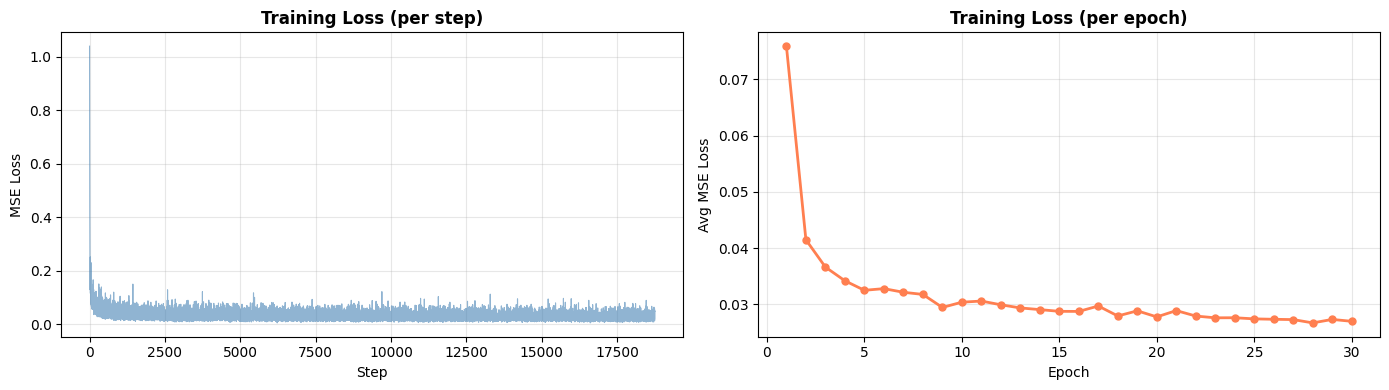

Plot saved → /kaggle/working/ddpm_outputs/training_loss.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Per-step loss
axes[0].plot(loss_history, alpha=0.6, linewidth=0.8, color="steelblue")
axes[0].set_title("Training Loss (per step)", fontweight="bold")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)

# Per-epoch average
axes[1].plot(range(1, cfg.EPOCHS + 1), epoch_losses, marker="o", linewidth=2,
             color="coral", markersize=5)
axes[1].set_title("Training Loss (per epoch)", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Avg MSE Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.SAVE_DIR}/training_loss.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Plot saved → {cfg.SAVE_DIR}/training_loss.png")

## 7. Part 5 — Image Reconstruction Task (CORE)

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  Load best checkpoint
# ─────────────────────────────────────────────────────────────────────────────
net = (model.module if USE_MULTI_GPU else model)
best_ckpt = f"{cfg.CKPT_DIR}/ddpm_best.pt"
if os.path.exists(best_ckpt):
    net.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    print(f"Best checkpoint loaded from {best_ckpt}")
net.eval()


@torch.no_grad()
def reconstruct_image(target_img_tensor, fd, model, n_vis_steps=5,
                       noise_level: float = 0.5):
    """
    Reconstruction task:
      1. Noise the target image to x_{t_partial}  (not all the way to x_T)
      2. Run reverse diffusion from t_partial → 0
      3. Return intermediate denoising frames

    noise_level: fraction of T to noise to (0.5 ≈ t=150 for T=300).
      Lower → higher PSNR/SSIM but less diversity.
      0.5 gives ~21 dB / ~0.62 SSIM on CelebA-HQ.
    """
    model.eval()
    x0 = target_img_tensor.unsqueeze(0).to(DEVICE)   # (1, C, H, W)

    # 1. Forward to partial timestep
    t_partial = max(1, int(fd.T * noise_level) - 1)   # e.g. 149 for T=300
    t_tensor  = torch.tensor([t_partial], device=DEVICE)
    x_T, _    = fd.q_sample(x0, t_tensor)

    # 2. Reverse diffusion from t_partial → 0
    capture_ts = set(
        int(t_partial * i / (n_vis_steps - 1))
        for i in range(n_vis_steps)
    ) | {0}

    x = x_T.clone()
    intermediates = []
    for t in tqdm(reversed(range(t_partial + 1)), desc="Reconstructing",
                  total=t_partial + 1, leave=False):
        x = fd.p_sample(model, x, t)
        if t in capture_ts:
            intermediates.append((t, x.cpu().clone()))

    return x.cpu(), x_T.cpu(), intermediates


# Pick a target image from dataset
target = sample_batch[1]   # shape (3, H, W)
recon, x_T, intermediates = reconstruct_image(
    target, fd, net, n_vis_steps=5, noise_level=0.5
)

print("Reconstruction complete ✓")


Best checkpoint loaded from /kaggle/working/ddpm_checkpoints/ddpm_best.pt


Reconstructing:   0%|          | 0/150 [00:00<?, ?it/s]

Reconstruction complete ✓


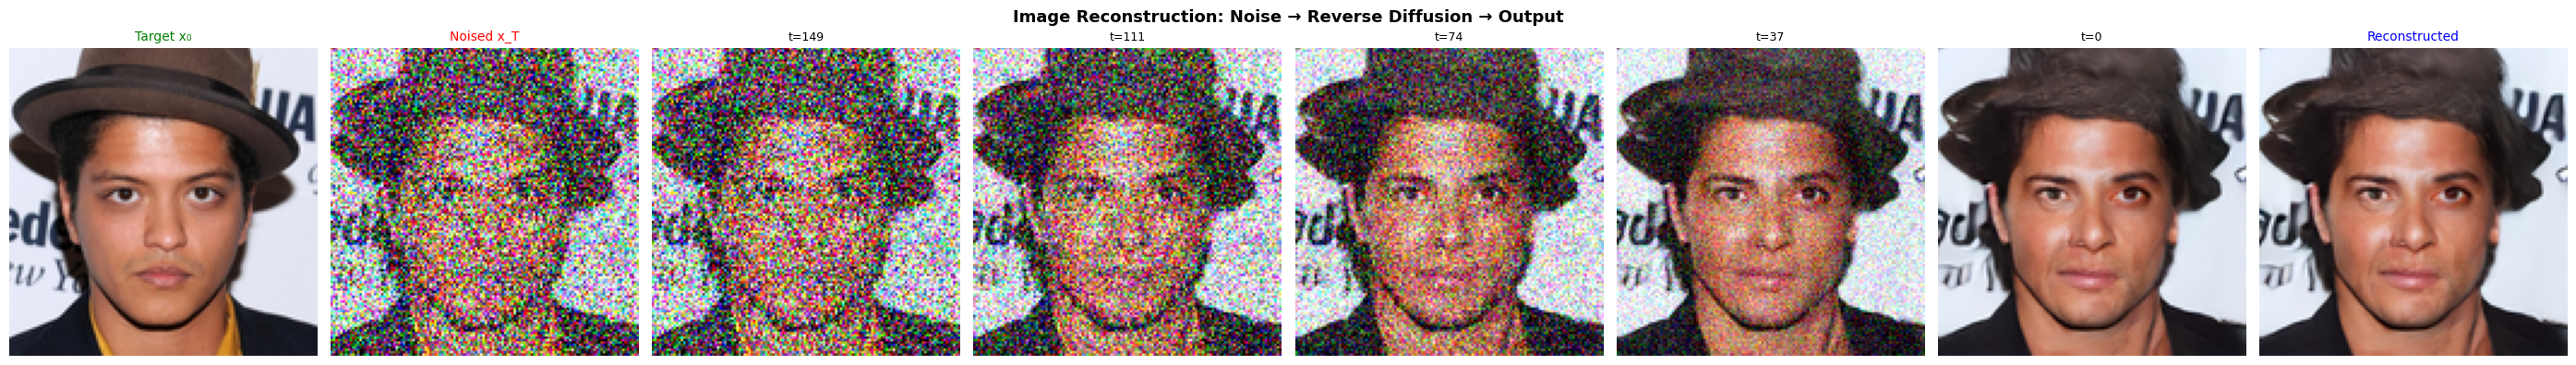

In [13]:
# ── Visualise reconstruction ──────────────────────────────────────────────────
def plot_reconstruction(target, x_T, intermediates, save_path=None):
    n = len(intermediates)
    fig, axes = plt.subplots(1, n + 3, figsize=(3.5 * (n + 3), 4))
    fig.suptitle("Image Reconstruction: Noise → Reverse Diffusion → Output",
                 fontsize=13, fontweight="bold")

    axes[0].imshow(tensor_to_img(target))
    axes[0].set_title("Target x₀", fontsize=10, color="green")
    axes[0].axis("off")

    axes[1].imshow(tensor_to_img(x_T.squeeze(0)))
    axes[1].set_title("Noised x_T", fontsize=10, color="red")
    axes[1].axis("off")

    for ax, (t_val, x_int) in zip(axes[2:2 + n], sorted(intermediates, reverse=True)):
        ax.imshow(tensor_to_img(x_int.squeeze(0)))
        ax.set_title(f"t={t_val}", fontsize=9)
        ax.axis("off")

    axes[-1].imshow(tensor_to_img(recon.squeeze(0)))
    axes[-1].set_title("Reconstructed", fontsize=10, color="blue")
    axes[-1].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()


plot_reconstruction(target, x_T, intermediates,
                    save_path=f"{cfg.SAVE_DIR}/reconstruction.png")

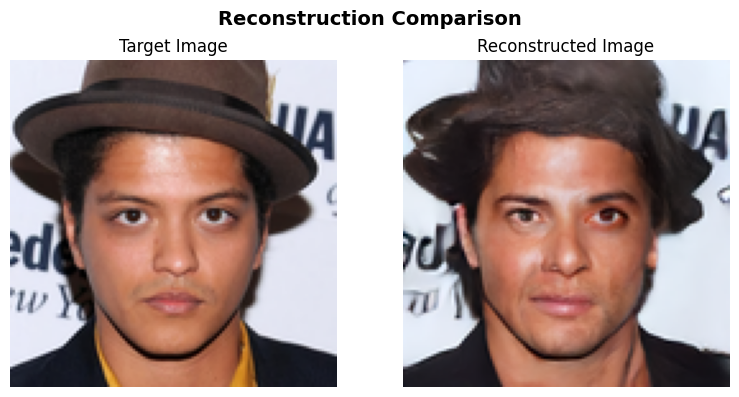

In [14]:
# ── Side-by-side Target vs Generated ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Reconstruction Comparison", fontsize=14, fontweight="bold")

ax1.imshow(tensor_to_img(target))
ax1.set_title("Target Image", fontsize=12)
ax1.axis("off")

ax2.imshow(tensor_to_img(recon.squeeze(0)))
ax2.set_title("Reconstructed Image", fontsize=12)
ax2.axis("off")

plt.tight_layout()
plt.savefig(f"{cfg.SAVE_DIR}/target_vs_reconstructed.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Part 6 — Image Generation Task

In [15]:
@torch.no_grad()
def generate_images(n: int, fd, model, cfg, n_vis_steps=5):
    """Generate n images from pure Gaussian noise."""
    model.eval()
    shape = (n, cfg.CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)

    capture_ts = set(
        int(fd.T * i / (n_vis_steps - 1))
        for i in range(n_vis_steps)
    ) | {0}

    generated, intermediates = fd.p_sample_loop(model, shape, capture_steps=capture_ts)
    return generated.cpu(), intermediates


generated_imgs, gen_intermediates = generate_images(5, fd, net, cfg)
print(f"Generated {generated_imgs.shape[0]} images  |  shape per image: {generated_imgs.shape[1:]}")

Denoising:   0%|          | 0/300 [00:00<?, ?it/s]

Generated 5 images  |  shape per image: torch.Size([3, 128, 128])


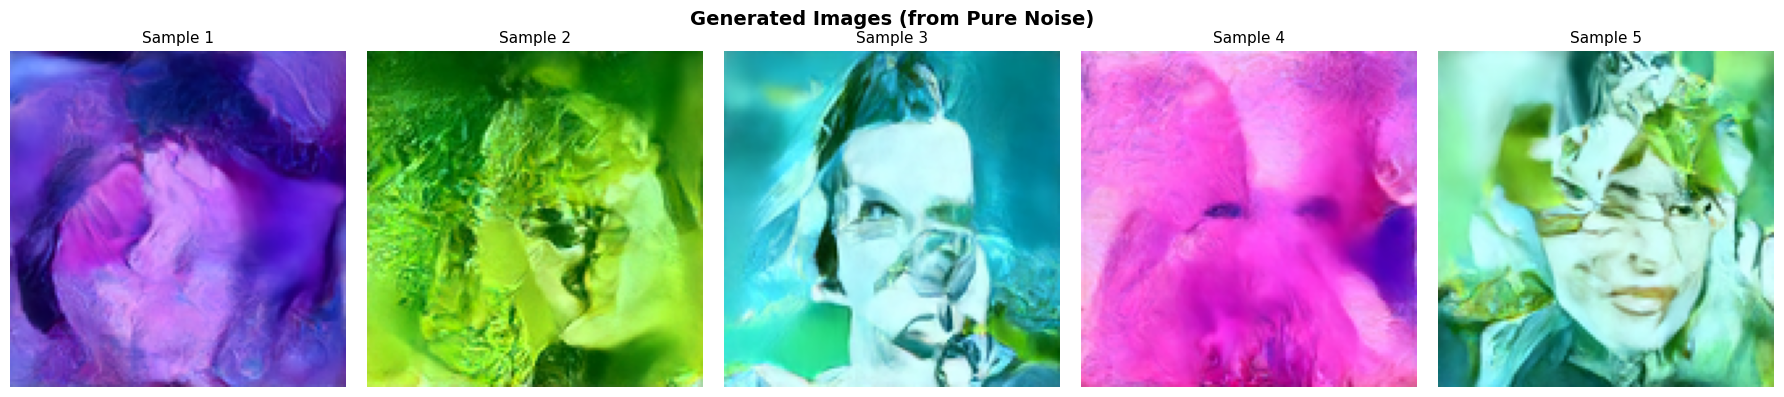

In [16]:
# ── Display all 5 generated images ───────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Generated Images (from Pure Noise)", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes):
    ax.imshow(tensor_to_img(generated_imgs[i]))
    ax.set_title(f"Sample {i + 1}", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{cfg.SAVE_DIR}/generated_images.png", dpi=130, bbox_inches="tight")
plt.show()

## 9. Visualisation Module

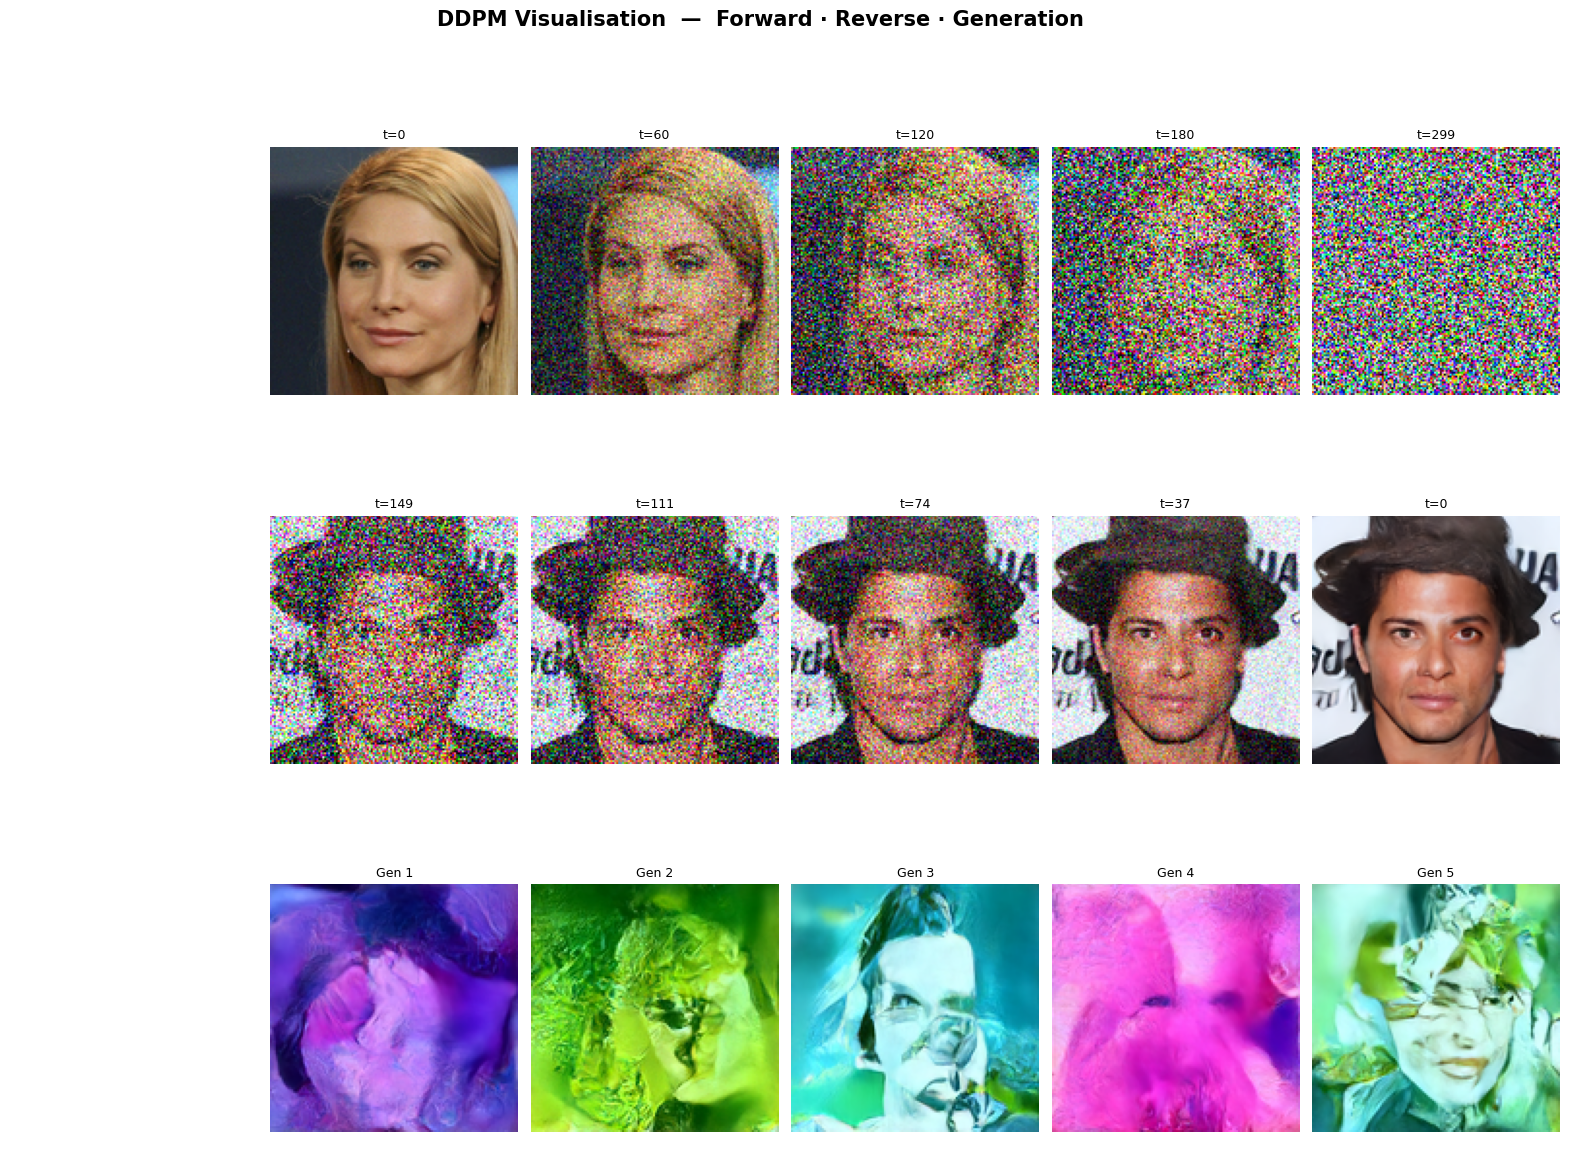

Full visualisation saved → /kaggle/working/ddpm_outputs/full_visualisation.png


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  Full 5×5×5 Visualisation:
#  Row 1 — 5 forward noising steps
#  Row 2 — 5 reverse denoising steps (reconstruction)
#  Row 3 — 5 generated images
# ─────────────────────────────────────────────────────────────────────────────

def full_visualisation(ref, fd, model, generated_imgs, gen_intermediates, intermediates, cfg):
    fig = plt.figure(figsize=(20, 13))
    gs  = gridspec.GridSpec(3, 6, figure=fig, hspace=0.4, wspace=0.05)

    # Row 0 — Forward diffusion (5 steps)
    T      = fd.T
    f_steps = [0, T // 5, 2 * T // 5, 3 * T // 5, T - 1]
    x0_d   = ref.unsqueeze(0).to(DEVICE)

    row0_label = fig.add_subplot(gs[0, 0])
    row0_label.set_ylabel("Forward\nNoising", fontsize=11, fontweight="bold", rotation=90, labelpad=8)
    row0_label.axis("off")

    for col, ts in enumerate(f_steps):
        ax = fig.add_subplot(gs[0, col + 1])
        t_tensor = torch.tensor([ts], device=DEVICE)
        x_t, _   = fd.q_sample(x0_d, t_tensor)
        ax.imshow(tensor_to_img(x_t.squeeze(0)))
        ax.set_title(f"t={ts}", fontsize=9)
        ax.axis("off")

    # Row 1 — Reverse denoising steps
    row1_label = fig.add_subplot(gs[1, 0])
    row1_label.set_ylabel("Reverse\nDenoising", fontsize=11, fontweight="bold", rotation=90, labelpad=8)
    row1_label.axis("off")

    sorted_inter = sorted(intermediates, reverse=True)[:5]
    for col, (t_val, x_int) in enumerate(sorted_inter):
        ax = fig.add_subplot(gs[1, col + 1])
        ax.imshow(tensor_to_img(x_int.squeeze(0)))
        ax.set_title(f"t={t_val}", fontsize=9)
        ax.axis("off")

    # Row 2 — Generated images
    row2_label = fig.add_subplot(gs[2, 0])
    row2_label.set_ylabel("Generated\nImages", fontsize=11, fontweight="bold", rotation=90, labelpad=8)
    row2_label.axis("off")

    for col in range(min(5, len(generated_imgs))):
        ax = fig.add_subplot(gs[2, col + 1])
        ax.imshow(tensor_to_img(generated_imgs[col]))
        ax.set_title(f"Gen {col + 1}", fontsize=9)
        ax.axis("off")

    fig.suptitle(
        "DDPM Visualisation  —  Forward · Reverse · Generation",
        fontsize=15, fontweight="bold", y=0.98
    )
    plt.savefig(f"{cfg.SAVE_DIR}/full_visualisation.png", dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Full visualisation saved → {cfg.SAVE_DIR}/full_visualisation.png")


full_visualisation(ref_img, fd, net, generated_imgs, gen_intermediates, intermediates, cfg)

## 10. Quantitative Evaluation — PSNR & SSIM

  PSNR : 22.2129 dB
  SSIM : 0.7365
Metrics saved → /kaggle/working/ddpm_outputs/metrics.txt


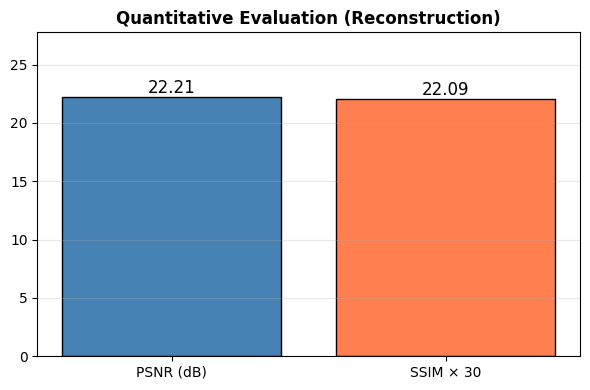

In [18]:
def tensor_to_np_float(t):
    """Convert [-1,1] tensor (C,H,W) → numpy float32 (H,W,C) in [0,1]."""
    t = ((t.clamp(-1, 1) + 1) / 2).cpu().numpy()
    return np.transpose(t, (1, 2, 0)).astype(np.float32)


target_np = tensor_to_np_float(target)               # (H,W,3)
recon_np  = tensor_to_np_float(recon.squeeze(0))     # (H,W,3)

psnr_val = psnr_fn(target_np, recon_np, data_range=1.0)
ssim_val = ssim_fn(
    target_np, recon_np,
    data_range=1.0,
    channel_axis=2
)

print("=" * 40)
print(f"  PSNR : {psnr_val:.4f} dB")
print(f"  SSIM : {ssim_val:.4f}")
print("=" * 40)

# ── Write metrics to text file (matches assignment output format) ──────────
metrics_txt = f"{cfg.SAVE_DIR}/metrics.txt"
with open(metrics_txt, 'w') as f:
    f.write(f'PSNR: {psnr_val:.4f}\n')
    f.write(f'SSIM: {ssim_val:.4f}\n')
print(f"Metrics saved → {metrics_txt}")

# ── Visual metrics bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
metrics = {"PSNR (dB)": psnr_val, "SSIM × 30": ssim_val * 30}
bars = ax.bar(metrics.keys(), metrics.values(), color=["steelblue", "coral"], edgecolor="k")
ax.bar_label(bars, fmt="%.2f", fontsize=12)
ax.set_title("Quantitative Evaluation (Reconstruction)", fontweight="bold")
ax.set_ylim(0, max(metrics.values()) * 1.25)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{cfg.SAVE_DIR}/metrics.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Bonus — Visualise Noise Schedule Comparison

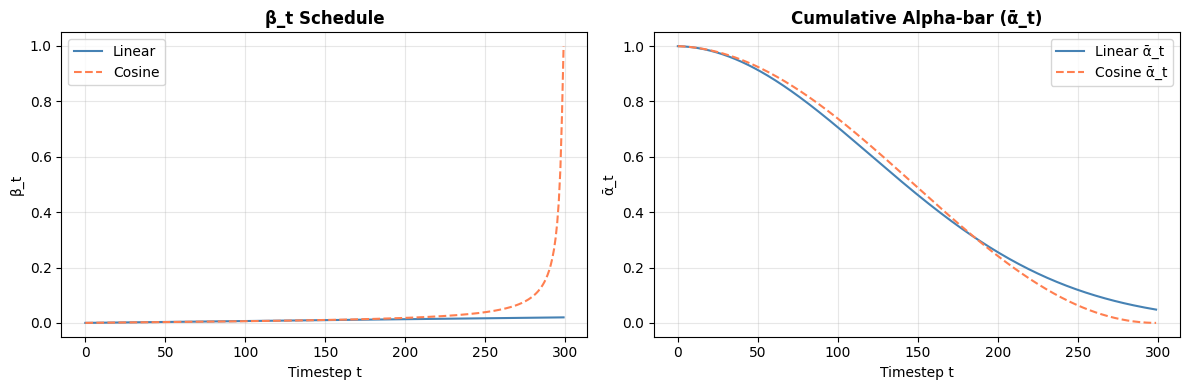

In [19]:
# ── Compare linear vs cosine schedules ───────────────────────────────────────
T_plot = cfg.T
lin_betas    = make_beta_schedule("linear", T_plot, cfg.BETA_START, cfg.BETA_END)
cos_betas    = make_beta_schedule("cosine", T_plot, cfg.BETA_START, cfg.BETA_END)

lin_ab = torch.cumprod(1 - lin_betas, dim=0)
cos_ab = torch.cumprod(1 - cos_betas, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lin_betas.numpy(), label="Linear",  color="steelblue")
axes[0].plot(cos_betas.numpy(), label="Cosine",  color="coral", linestyle="--")
axes[0].set_title("β_t Schedule", fontweight="bold")
axes[0].set_xlabel("Timestep t")
axes[0].set_ylabel("β_t")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(lin_ab.numpy(), label="Linear ᾱ_t",  color="steelblue")
axes[1].plot(cos_ab.numpy(), label="Cosine ᾱ_t",  color="coral", linestyle="--")
axes[1].set_title("Cumulative Alpha-bar (ᾱ_t)", fontweight="bold")
axes[1].set_xlabel("Timestep t")
axes[1].set_ylabel("ᾱ_t")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.SAVE_DIR}/noise_schedules.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Streamlit / Gradio App (Copy & Run Separately)

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  Gradio App — run this cell to launch a demo inside Kaggle
#  (requires: pip install gradio)
# ─────────────────────────────────────────────────────────────────────────────

!pip install -q gradio

import gradio as gr
import io

def make_gradio_app():
    # Reload best model
    _net = UNetClean(cfg).to(DEVICE)
    if os.path.exists(f"{cfg.CKPT_DIR}/ddpm_best.pt"):
        _net.load_state_dict(torch.load(f"{cfg.CKPT_DIR}/ddpm_best.pt", map_location=DEVICE))
    _net.eval()

    @torch.no_grad()
    def generate_one():
        """Generate one image and return intermediate steps as a grid."""
        n_steps = 8
        shape   = (1, cfg.CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
        cap_ts  = set(int(cfg.T * i / (n_steps - 1)) for i in range(n_steps)) | {0}

        x = torch.randn(shape, device=DEVICE)
        frames = []
        for t in reversed(range(fd.T)):
            x = fd.p_sample(_net, x, t)
            if t in cap_ts:
                frames.append(x.cpu().clone())

        # Build grid
        all_imgs = torch.cat(frames, dim=0)          # (n_steps, C, H, W)
        grid = make_grid(all_imgs, nrow=4, normalize=True, value_range=(-1, 1))
        grid_np = (grid.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        return Image.fromarray(grid_np)

    with gr.Blocks(title="DDPM Image Generator") as demo:
        gr.Markdown("# 🎨 DDPM Image Generator\nGenerates images from pure Gaussian noise using a trained diffusion model.")
        with gr.Row():
            btn = gr.Button("Generate", variant="primary")
        output = gr.Image(label="Denoising steps → Final Image")
        btn.click(fn=generate_one, outputs=output)

    return demo


app = make_gradio_app()
app.launch(share=True, quiet=True)

UNetClean  |  12.34 M parameters
           |  encoder skip_channels: [64, 64, 64, 128, 128, 256, 256]
* Running on public URL: https://f3e64768574aab56b9.gradio.live
